# PERGUNTA 5

# Evolução temporal.

Importando as Blibliotecas **pandas, numpy e matplotlib.pylot**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Criando **FUNÇÃO** para carregar um arquivo **csv**

In [2]:
def carregar_banco_csv(caminho):
    return pd.read_csv(caminho)
    pass

Puxando a **FUNÇÃO** através da **VARIÁVEL**, e retornando o **BANCO DE DADOS**

In [3]:
df = carregar_banco_csv(
    r"C:\Users\User\Desktop\BECKUP - PALMEIRAS\CAIXAVERSO - ADA\AULAS PRESENCIAIS\4 - TECNICAS DE PROGRAMAÇÃO I (PY) - DE 12-05-2026 A 26-05-2026\PROJETO\salario_ciencia_dados.csv"
)
df.head()

,cargo,nivel_experiencia,tipo_contrato,modalidade,ano,pais_residencia,salario_moeda_corrente,moeda_corrente,salario_usd,pais_empresa,porte_empresa
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


# Como os salários médios variaram de 2020 a 2024?

In [4]:
anos = sorted(df["ano"].unique(), reverse=False)
# Lista para armazenar os resultados
salarios = []
for ano in anos:
    # Filtrar apenas os dados do ano atual
    df_ano = df[df["ano"] == ano]
    # Média salarial geral nesse ano
    salario_medio = df_ano["salario_usd"].mean().round(2)
    # Adicionar ao resultado
    salarios.append({
        "Ano": ano,
        "Média Salarial (USD)": salario_medio
    })
media_salario = df["salario_usd"].mean().round(2)
salarios.append({
    "Ano": "TODOS",
    "Média Salarial (USD)": media_salario
})
# Converter em DataFrame
tabela_salarios = pd.DataFrame(salarios)
print(tabela_salarios.to_string(index=False))


  Ano  Média Salarial (USD)
 2020             102250.87
 2021              99501.29
 2022             131788.54
 2023             150791.42
 2024             153124.08
TODOS             145560.56


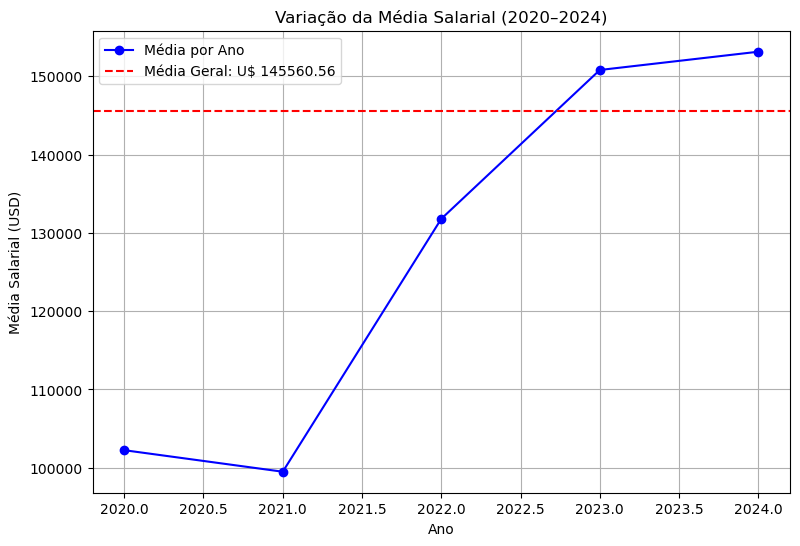

In [5]:
# Remover a linha "TODOS" para o gráfico principal
df_plot = tabela_salarios[tabela_salarios["Ano"] != "TODOS"]
plt.figure(figsize=(9,6))
# Gráfico de linha com pontos
plt.plot(df_plot["Ano"], df_plot["Média Salarial (USD)"], 
         marker="o", linestyle="-", color="blue", label="Média por Ano")
# Adicionar linha da média geral
media_geral = tabela_salarios.loc[tabela_salarios["Ano"] == "TODOS", "Média Salarial (USD)"].values[0]
plt.axhline(y=media_geral, color="red", linestyle="--", label=f"Média Geral: U$ {media_geral}")
# Título e rótulos
plt.title("Variação da Média Salarial (2020–2024)")
plt.xlabel("Ano")
plt.ylabel("Média Salarial (USD)")
plt.legend()
plt.grid(True)
plt.show()

# Houve mudanças significativas na modalidade de trabalho (mais remoto, menos remoto) no período?

In [6]:
anos = sorted(df["ano"].unique(), reverse=False)
# Lista para armazenar os resultados
remotos = []
for ano in anos:
    # Filtrar apenas os dados do ano atual
    df_ano = df[df["ano"] == ano]  
    # Filtrar apenas funcionários remotos nesse ano
    df_remoto = df_ano[df_ano["modalidade"] == "Remote"]
    # Quantidade de funcionários remotos
    qtd_remotos = len(df_remoto)
    # Média salarial dos funcionários remotos
    media_salario = df_remoto["salario_usd"].mean().round(2) if qtd_remotos > 0 else 0
    # Adicionar ao resultado
    remotos.append({
        "Ano": ano,
        "Qtd Funcionários Remotos": qtd_remotos,
        "Média Salarial Remotos (USD)": media_salario
    })
# Converter em DataFrame
tabela_remotos = pd.DataFrame(remotos)
print(tabela_remotos.to_string(index=False))

 Ano  Qtd Funcionários Remotos  Média Salarial Remotos (USD)
2020                        36                     115214.08
2021                       115                     109121.84
2022                       617                     134176.04
2023                      1657                     145490.17
2024                       136                     142561.49


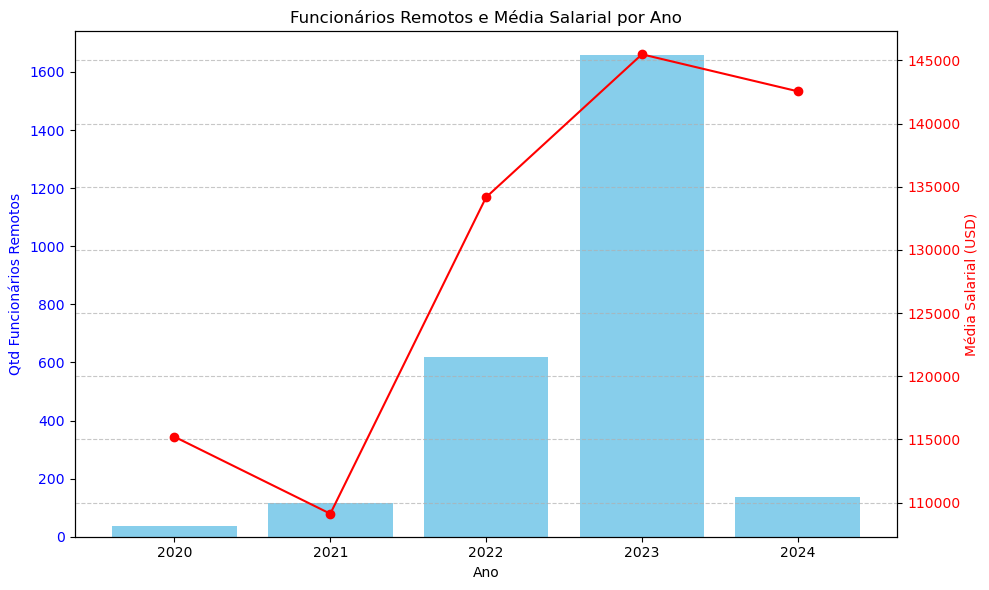

In [7]:
# Criar gráfico combinado
fig, ax1 = plt.subplots(figsize=(10,6))
# Barras para quantidade de funcionários remotos
ax1.bar(tabela_remotos["Ano"], tabela_remotos["Qtd Funcionários Remotos"], 
        color="skyblue", label="Qtd Funcionários Remotos")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Qtd Funcionários Remotos", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
# Criar segundo eixo Y para média salarial
ax2 = ax1.twinx()
ax2.plot(tabela_remotos["Ano"], tabela_remotos["Média Salarial Remotos (USD)"], 
         marker="o", color="red", label="Média Salarial Remotos")
ax2.set_ylabel("Média Salarial (USD)", color="red")
ax2.tick_params(axis="y", labelcolor="red")
# Título e grade
plt.title("Funcionários Remotos e Média Salarial por Ano")
fig.tight_layout()
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
# Mostrar gráfico
plt.show()